# Fall 2025 AE-311 Project 1 - Part 1 

# Numerical solution of the 2-body problem

Modified by: <br>
<!-- + Write your name below + -->      
<br>
Kaoutar Ammara <br>
Department of Aerospace Engineering <br>
Izmir University of Economics <br> 

email: a.kaoutar2001@gmail.com 

**Instructor** Fabrizio Pinto

Created: 20 September 2022<br>
Last revised: 16December 2025 <br>  



<span style='color:red'>  **This is ver. 1.3 of this document. Any needed updates will appear as separate, follow-up versions.**</span> 

<div class="alert alert-block alert-info">
<span style='color:black'>  "Numerical solution of the 2-body problem" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

 <div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 

## <a class="anchor" id="Table_of_Contents"></a> Table of Contents 

[Abstract](#Abstract) 

[1. Constants and useful parameters](#1_Constants_and_useful_parameters)

[2. Numerical solution](#2_Numerical_solution)

&emsp; [2.1 Radial coordinate](#2.1_Radial_coordinate) 

&emsp; [2.2 Angular coordinate](#2.2_Angular_coordinate) 

&emsp; [2.3 Trajectory](#2.3_Trajectory)

[3. Analytical solution](#3_Analytical_solution)

[4. Error analysis](#4_Error_analysis)

&emsp; [4.1 Energy conservation](#4.1_Energy_conservation)

&emsp; [4.2 Angular_momentum_conservation](#4.2_Angular_momentum_conservation)

&emsp; [4.3 Comparison of position from the numerical and analytical calculations](#4.3_Comparison_of_position)

[5. Questions](#5_Questions) 

[References](#References) 

[Additional reading](#Additional_reading) 

## <a class="anchor" id="Abstract"></a> Abstract 

[Back to Table of Contents](#Table_of_Contents)

In this notebook, we compute the numerical solution of the Newtonian two-body problem and compare it to the analytical Kepler solution. Using Mercury's orbital parameters, we solve the radial and angular differential equations, construct the numerical trajectory, derive the analytical orbit, and quantify the numerical errors in energy, angular momentum, and position.

## <a class="anchor" id="1_Constants_and_useful_parameters"></a> 1. Constants and useful parameters

[Back to Table of Contents](#Table_of_Contents)  

Only SI units are used: 

In [33]:
SiderealDay = 86164.0905 ;

kSun = 1.32712440041279419 10^(20); 

raMercury = 69.82 10^9 ;
rpMercury = 46.00 10^9 ; 

TPerMercury = 87.9691 SiderealDay 

6
7.57978 10

## <a class="anchor" id="2_Numerical_solution"></a> 2. Numerical solution

[Back to Table of Contents](#Table_of_Contents)   

As an example, let us consider the motion of the planet Mercury, whose perihelion and aphelion values are given above. With these values, the magnitude of the *specific* angular momentum, ${\mathbf{\ell}} = |{\mathbf{L}}|/m =|{\mathbf{r}}\times {\mathbf{v}}|$ and, for instance, the entirely tangential speed at aphelion are as follows:

In [42]:
SemiMajor[ra_,rp_]= (1/2)(ra+rp);
Eccentricity[ra_,rp_]=(ra-rp)/(ra+rp);

SpecAngMomenIn [ra_,rp_]= Sqrt[kSun SemiMajor[ra,rp] (1-(Eccentricity[ra,rp])^2) ];
vt0In[ra_,rp_]=(SpecAngMomenIn [ra,rp])/ra ;

In [46]:
vt0In[69.82 10^9,46 10^9]

38856.9

Let us express the initial conditions in terms of the aphelion distance and the speed at aphelion; the specific angular momentum is given by the product ${\mathbf{\ell}} = r_a v_a$. This latter expression is useful if the initial conditions are not obtained from knowledge of the orbit elements $a$ and $e$ but simply from $r_a$ and $v_a$:

In [51]:
r0 =69.82 10^9 ;
vt0 = vt0In[69.82 10^9,46 10^9];

lSpecAngMom[r0_,vt0_] =  r0 vt0 

15
2.71299 10

Final time is set so as to complete at least one revolution, as seen from the period of revolution given above, $T_{\mathrm{Mercury}} \simeq 7.6\times 10^6$ s:

In [58]:
tfin = 10^7 ;
N[tfin/86400]

115.741

### <a class="anchor" id="2.1_Radial_coordinate"></a> 2.1 Radial coordinate

[Back to Table of Contents](#Table_of_Contents)   


Theoretical considerations quickly show that, for central forces, the angular momentum is conserved. This is a statement of **Kepler's 2nd Law** (see Bate Sec. 1.4.2 and Eq. (1.7.7) and Kittel p. 281):

$$
{1\over m}{\mathrm{d} {\mathbf L}\over \mathrm{d} t} = {\mathrm{d} \over \mathrm{d} t} (\mathbf{r}\times \mathbf{v}) = \mathbf{0}.
$$

The conservation of the angular momentum allows us to eliminate the variable $\dot{\theta}$ from the differential equation for the radial variable, which can now be integrated numerically with respect to the time independent variable to find the solution $r(t)$. Notice that this is *not* done analytically as the time variable is replaced by the angular variable and the problem solved analytically is that of finding $r(\theta)$. The numerical solution for the radial coordinate is:

7
{0.15625, {{r -> InterpolatingFunction[{{0., 1. 10 }}, <>]}}}
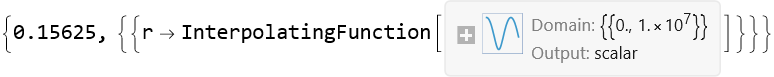

In [72]:
Timing[SolKeplerRad =NDSolve[{r''[t] == (lSpecAngMom[r0,vt0])^2 (1/(r[t])^3) - (kSun/(r[t])^2) ,r[0]==r0,r'[0]==+0.},r,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

Note the computation time for future use, also given by:

In [77]:
%[[1]]

hashlib

In the Mathematica syntax for the `NDSolve` above, the solution process was named SolKeplerRad. We can now define functions for the radial coordinate, $r(t)$, the radial velocity component, $\dot{r}(t)$, the angular velocity, $\dot{\theta}(t)$, and the tangential velocity component, $v_t(t)$, based on the results of the numerical integration:

In [82]:
rSol[t_] = Evaluate[r[t] /. SolKeplerRad][[1]];

rDotSol[t_] = Evaluate[r'[t] /. SolKeplerRad][[1]];

ThetaAngDot[t_] = (lSpecAngMom[r0,vt0])(1/(rSol[t])^2);
vtSol[t_] = ThetaAngDot[t]rSol[t] ;

The oscillating radial coordinate can be used to numerically determine the period of revolution, $T_{\mathrm{Mercury, Num}}$. In order to do so, we must just find the first time, following the initial time ($t=0$), that the radial coordinate reaches a maximum, that is, that the object is back to aphelion, so that $r(T_{\mathrm{Mercury, Num}}) = r_a$:

-Graphics-
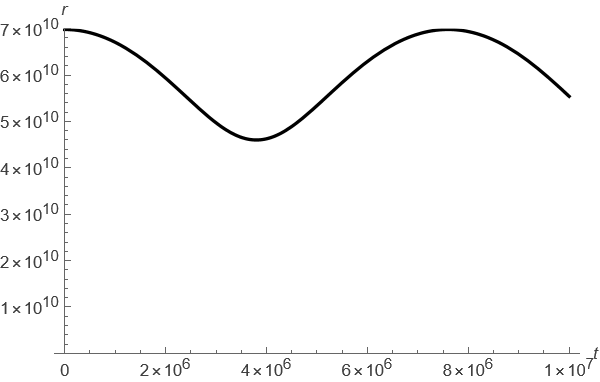

In [90]:
PLOT1 = Plot[rSol[t],{t,0, tfin},PlotRange->{0, 7 10^(10)},AxesLabel->{t,r}, PlotStyle->{Black, Thick}]

In [91]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-1-radial-solution.pdf", PLOT1] 

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-1-radial-soluti\
 
>   on.pdf

By starting the search after $t_{\mathrm{fin}}/2$ so as to avoid the obvious solution at $t=0$, the period in seconds and in days is:

In [96]:
PeriodRevNum = FindMaximum[rSol[t], {t,tfin/2, tfin} ][[2,1,2]] 
PeriodRevNumDays = FindMaximum[rSol[t], {t,tfin/2, tfin} ][[2,1,2]] /86400

6
7.60071 10
87.9712

The relative error with respect to the listed period of revolution is:

In [102]:
(TPerMercury - PeriodRevNum)/TPerMercury 

-0.00276217

Plot also the other quantities as a function of time:

-Graphics-
-Graphics-
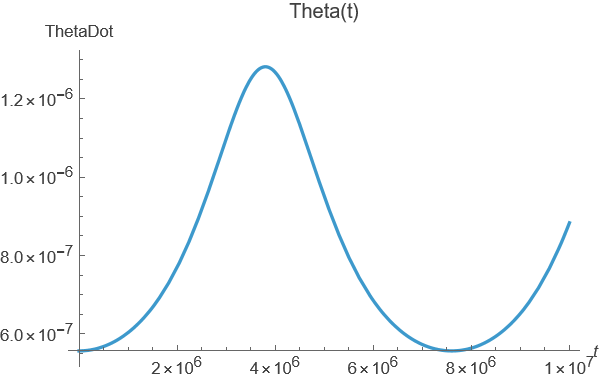
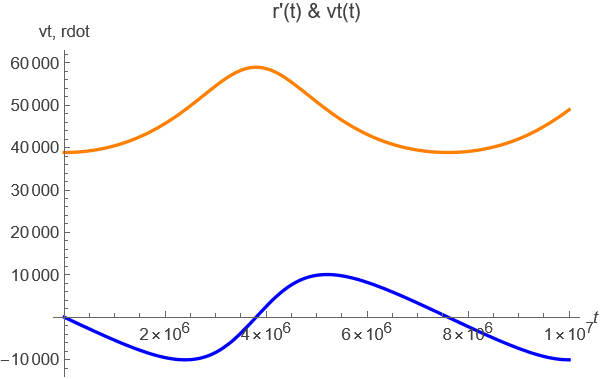

In [107]:
PLOT1B = Plot[ThetaAngDot[t],{t,0, tfin},PlotRange->All,PlotRange->All,AxesLabel->{t,ThetaDot},PlotLabel->"Theta(t)"]

PLOT1C = Plot[rDotSol[t],{t,0, tfin},PlotRange->All,PlotStyle-> Blue,AxesLabel->{t,"vt, rdot"},PlotLabel->"r'(t) & vt(t)"];
PLOT1D = Plot[vtSol[t],{t,0, tfin},PlotRange->All,PlotStyle-> Orange,PlotLabel->"r'(t) & vt(t)"];
Show[PLOT1C,PLOT1D]

### <a class="anchor" id="2.2_Angular_coordinate"></a> 2.2 Angular coordinate

[Back to Table of Contents](#Table_of_Contents)   


The differential equation for the angular coordinate is given by the conservation of the angular momentum (Kittel, Eq. 9.21):

$$
{{\mathrm{d}}\theta\over {\mathrm{d}} t} = {\ell\over r^2(t)}\, ,
$$

where $r(t)$ is the numerical solution found in the previous section. Since this is a $1$st order differential equation, we need only one initial condition, which we choose as $\theta(0)=0$: 

7
{{ThetaAng -> InterpolatingFunction[{{0., 1. 10 }}, <>]}}
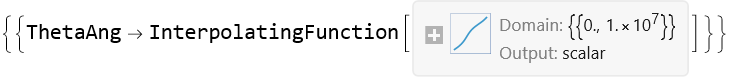

In [115]:
SolKeplerAng =NDSolve[{ThetaAng'[t] == (lSpecAngMom[r0,vt0])(1/(rSol[t])^2) ,ThetaAng[0]==0},ThetaAng,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]

As shown above, we can define a function based on the results: 

7
InterpolatingFunction[{{0., 1. 10 }}, <>][t]
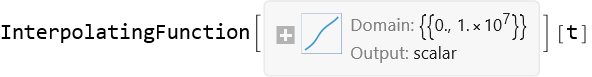

In [120]:
ThetaAngSol[t_] = Evaluate[ThetaAng[t] /. SolKeplerAng][[1]]

and we can show a plot the angular coordinate as a function of time:

-Graphics-
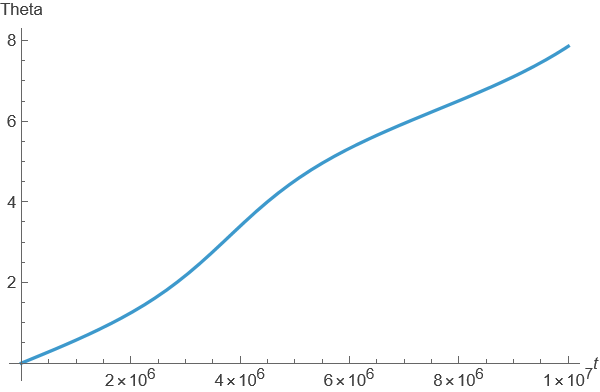

In [125]:
PLOT2 = Plot[ThetaAngSol[t],{t,0, tfin},PlotRange->All,PlotRange->{0, 2 Pi},AxesLabel->{t,Theta}]

### <a class="anchor" id="2.3_Trajectory"></a> 2.3 Trajectory 

[Back to Table of Contents](#Table_of_Contents)   

One strategy to plot the trajectory is to transform the above results from polar to Cartesian coordinates: 

In [130]:
xSol[t_] = rSol[t] Cos[ThetaAngSol[t]];
ySol[t_] = rSol[t] Sin[ThetaAngSol[t]];

These are plot of the Cartesian coordinates as functions of time:

-Graphics-
-Graphics-
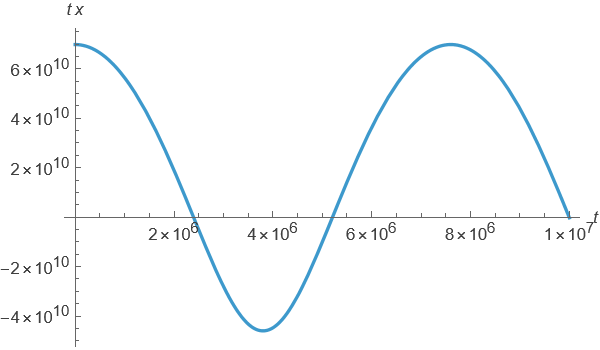
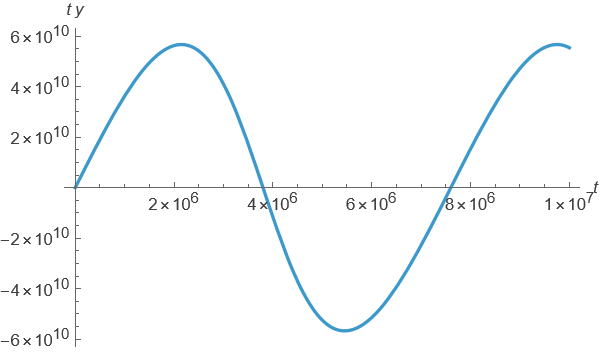

In [136]:
PLOTxSol3 = Plot[xSol[t],{t,0, tfin},PlotRange->All,PlotRange->All, Axes-> True, AxesLabel->{t,x(t)}]
PLOTySol3 = Plot[ySol[t],{t,0, tfin},PlotRange->All,PlotRange->All, Axes-> True, AxesLabel->{t,y(t)}]

The trajectory can be shown numerically by creating a parametric plot of the curve 

$$\eqalign{
& x = r(t)\cos\theta(t)\, ,\\
& y = r(t)\sin\theta(t)\, .
}
$$

as shown below (the Sun is to the correct scale):

-Graphics-
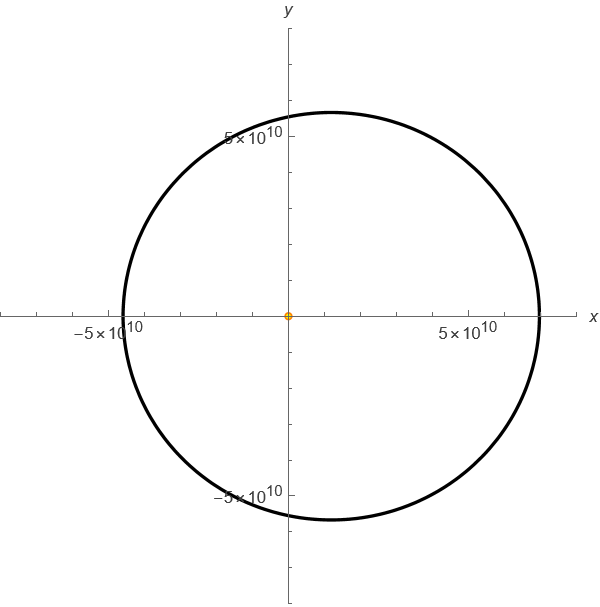

In [142]:
PLOTMercuryTraj = ParametricPlot[{xSol[t],ySol[t]},{t,0,0.9999 PeriodRevNum},Axes->True,AxesLabel->{x,y},
PlotStyle->Black, PlotRange -> {{- 8 10^(10), 8 10^(10)}, {- 8 10^(10), 8 10^(10)}} ];

PLOTSunEdge = Graphics[{Orange,Thick,Circle[{0,0},6.96 10^8]} ,Axes->True,AxesLabel->{x,y}];
PLOTSunDisk = Graphics[{Yellow,Disk[{0,0},6.96 10^8]} ];
PLOTSun = Show[PLOTSunEdge,PLOTSunDisk];

PlotNumerAll  = Show[PLOTSun,PLOTMercuryTraj,PlotRange -> {{- 8 10^(10), 8 10^(10)}, {- 8 10^(10), 8 10^(10)}}]

In [147]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-2-numerical-trajectory.pdf", PlotNumerAll] 

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-2-numerical-tra\
 
>   jectory.pdf

## <a class="anchor" id="3_Analytical_solution"></a> 3. Analytical solution

[Back to Table of Contents](#Table_of_Contents)   

The analytical solution for the trajectory, $r=r(\theta)$ can be written by computing the conserved quantities from the initial conditions (assuming an initial position at either peri- or apoapsis), that is, the specific energy, $\cal{E}$, and the magnitude of the specific angular momentum, $\ell$. From the theory of the $2$-body problem, we obtain the eccentricity, $e$, the semimajor axis, $a$, and the semilatus rectum, $p$ (see Bate and Kittel):


In [152]:
SpecEnergy[rAnalyt0_,vtAnalyt0_] = (1/2)(vtAnalyt0)^2 - (kSun/rAnalyt0) ;
SpecAngMomen[rAnalyt0_,vtAnalyt0_] =rAnalyt0 vtAnalyt0  ;

Eccentricity[rAnalyt0_,vtAnalyt0_] =Sqrt[1+(2 SpecEnergy [rAnalyt0,vtAnalyt0](SpecAngMomen[rAnalyt0,vtAnalyt0])^2/kSun^2)] ;
SemiMajorAxis [rAnalyt0_,vtAnalyt0_] = -kSun/(2  SpecEnergy[rAnalyt0,vtAnalyt0]) ;
SemiLatus[rAnalyt0_,vtAnalyt0_] =SemiMajorAxis [rAnalyt0,vtAnalyt0](1-(Eccentricity[rAnalyt0,vtAnalyt0])^2);

In [157]:
SpecEnergy[69.82 10^9,38.8569 10^3] 
SpecAngMomen[69.82 10^9,38.8569 10^3]
Eccentricity[69.82 10^9,38.8569 10^3]
SemiMajorAxis [69.82 10^9,38.8569 10^3]
SemiLatus[69.82 10^9,38.8569 10^3]

9
-1.14585 10
          15
2.71299 10
0.205664
        10
5.791 10
          10
5.54606 10

The trajectory equation reads, assuming $r(\theta=0) = r_a$:

$$
r (\theta) = {a (1-e^2)\over 1 -e \cos\theta}
$$

In [166]:
rAnalyt[rAnalyt0_,vtAnalyt0_,ThetaAnalyt_] = SemiLatus[rAnalyt0,vtAnalyt0]/(1 - Eccentricity[rAnalyt0,vtAnalyt0] Cos[ThetaAnalyt]) ;

10
6.982 10
                  10
        5.54606 10
-----------------------------
1 - 0.205664 Cos[ThetaAnalyt]
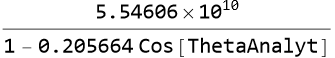

In [167]:
rAnalyt[69.82 10^9,38.8569 10^3,0]
rAnalyt[69.82 10^9,38.8569 10^3,ThetaAnalyt]

By again transforming from polar to Cartesian coordinates and creating a parametric plot:

In [173]:
xAnalyt[rAnalyt0_,vtAnalyt0_,ThetaAnalyt_] = rAnalyt[rAnalyt0,vtAnalyt0,ThetaAnalyt] Cos[ThetaAnalyt];
yAnalyt[rAnalyt0_,vtAnalyt0_,ThetaAnalyt_] = rAnalyt[rAnalyt0,vtAnalyt0,ThetaAnalyt] Sin[ThetaAnalyt];

-Graphics-
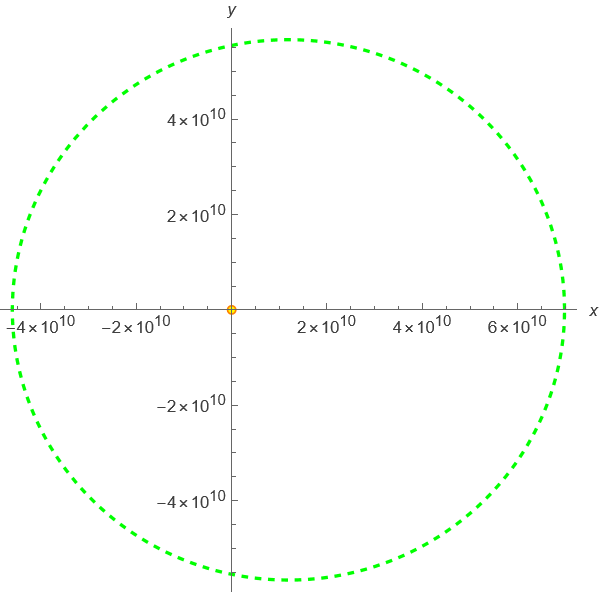

In [175]:
PLOTMercuryTrajAnalyt = ParametricPlot[{xAnalyt[69.82 10^9,38.8569 10^3,ThetaAnalyt],yAnalyt[69.82 10^9,38.8569 10^3,ThetaAnalyt]},{ThetaAnalyt,0,2 Pi},Axes->True,AxesLabel->{x,y},PlotStyle->{Dashed,Green}];

PlotAnalytAll  =Show[PLOTSun,PLOTMercuryTrajAnalyt]

In [177]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-3-analytical-trajectory.pdf", PlotAnalytAll] 

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-3-analytical-tr\
 
>   ajectory.pdf

A first comparison of the numerical and of the analytical results can be carried out visually by superimposing the results:

-Graphics-
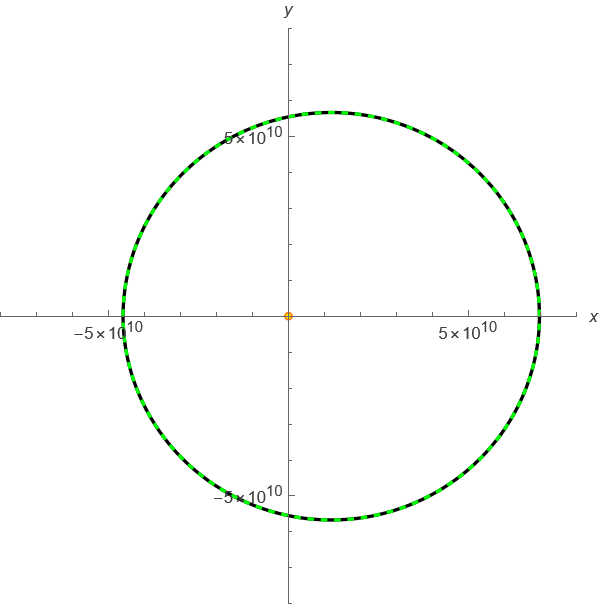

In [182]:
PLOTNumAnalytc = Show[PlotNumerAll,PlotAnalytAll] 

It may be useful to export this diagram to a PDF plot:

In [187]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-4-combined-orbits.pdf", PLOTNumAnalytc] 

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-4-combined-orbi\
 
>   ts.pdf

We can conclude this Section by computing the period of revolution from the theory of the $2$-body problem:

$$
T = {2\pi\over \sqrt{k_\odot}}\, a^{3/2}\, .
$$

In [192]:
RevolutionPeriod[rAnalyt0_,vtAnalyt0_]= 2 Pi Sqrt[(SemiMajorAxis [rAnalyt0,vtAnalyt0] )^3/kSun] ;

In [193]:
RevolutionPeriod[69.82 10^9,38.8569 10^3]
RevolutionPeriod[69.82 10^9,38.8569 10^3]/(86400)

6
7.60072 10
87.9713

We can now compare this to the period of revolution computed numerically:

In [199]:
PeriodRevNum
RevolutionPeriod[69.82 10^9,38.8569 10^3]
(RevolutionPeriod[69.82 10^9,38.8569 10^3] - PeriodRevNum)/RevolutionPeriod[69.82 10^9,38.8569 10^3]

6
7.60071 10
          6
7.60072 10
          -7
5.52771 10

## <a class="anchor" id="4_Error_analysis"></a> 4. Error analysis

[Back to Table of Contents](#Table_of_Contents) 



Since an analytical solution is available, we can compare the position calculated numerically with the exact result. Furthermore, we can check the accuracy of the requirement of energy and angular momentum conservation. 

### <a class="anchor" id="4.1_Energy_conservation"></a> 4.1 Energy conservation 

[Back to Table of Contents](#Table_of_Contents)   

Here we calculate the initial specific energy and compute the relative change of energy at NMax points, which are stored in an array and plotted: 

In [214]:
NMax = 100

DeltaEnergy = Array[f,NMax+1] ;
TimeArray = Array[k,NMax+1];

SpecEnergy0 = (1/2)(vt0)^2- (kSun/r0)

Do[tTest = N[(tfin /NMax)] (i-1)  ;
SpecEnergyNum = (1/2)((rDotSol[tTest])^2  + (vtSol[tTest])^2)- (kSun/rSol[tTest]);
TimeArray[[i]]= tTest;
DeltaEnergy [[i]]=SpecEnergyNum - SpecEnergy0,{i,1,NMax+1}];

SpecEnergyNumArray = Partition[Riffle[TimeArray  ,DeltaEnergy/SpecEnergy0],2];

100
           9
-1.14585 10

-Graphics-
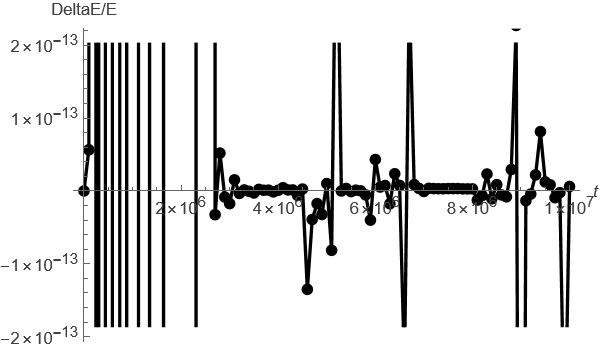

In [220]:
PLOTDeltaEnergy1= ListPlot[SpecEnergyNumArray,PlotStyle->{Black} ,Joined->True,PlotMarkers->Automatic,AxesLabel->{t,"DeltaE/E"}]

In [221]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-5-relative-energy-error.pdf", PLOTDeltaEnergy1] 

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-5-relative-ener\
 
>   gy-error.pdf

### <a class="anchor" id="4.2_Angular_momentum_conservation"></a> 4.2 Angular momentum conservation  

[Back to Table of Contents](#Table_of_Contents)   

Here we calculate the initial specific angular momentum and compute its relative change at NMax points, which are stored in an array and plotted: 

**Q:** How would you implement this check? You can either use Mathematica or pseudocode. Write in cells *below*. 

In [230]:
NMax = 100

DeltalSpecAngMom = Array[f,NMax+1] ;
TimeArray = Array[k,NMax+1];

lSpecAngMom0 = (r0)*(vt0)

Do[tTest = N[(tfin /NMax)] (i-1)  ;
lSpecAngMomNum = (rSol[tTest])*(vtSol[tTest]);
TimeArray[[i]]= tTest;
DeltalSpecAngMom [[i]]=lSpecAngMomNum - lSpecAngMom0,{i,1,NMax+1}];

lSpecAngMomNumArray = Partition[Riffle[TimeArray ,DeltalSpecAngMom/lSpecAngMom0],2];

100
          15
2.71299 10

-Graphics-
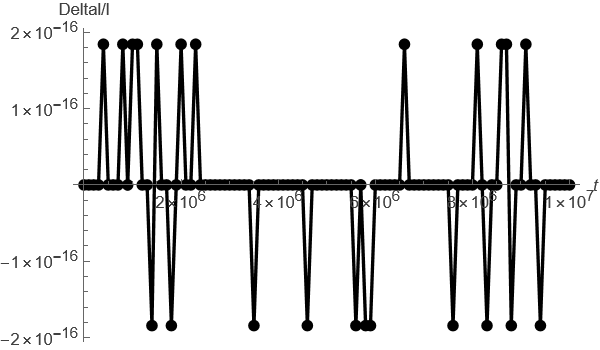

In [236]:
PLOTDeltaAngMom1= ListPlot[lSpecAngMomNumArray,PlotStyle->{Black} ,Joined->True,PlotMarkers->Automatic,AxesLabel->{t,"Deltal/l"}]

In [237]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q2-fig-6.pdf", PLOTDeltaAngMom1]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q2-fig-6.pdf

### Interpretation

The computed relative variation in angular momentum,$$\frac{l(t) - l_0}{l_0},$$ remains extremely small throughout the simulation, with values on the order of  $10^{-16}$
.This indicates that the numerical solver preserves angular momentum with near machine precision accuracy.



### <a class="anchor" id="4.3_Comparison_of_position"></a> 4.3 Comparison of position from the numerical and analytical calculations

[Back to Table of Contents](#Table_of_Contents)   

Here we compare the results for the $x$ and $y$ coordinates.

In [246]:
NMax = 100;

DeltaxtTest = Array[f,NMax+1] ;
DeltaytTest = Array[f,NMax+1] ;
TimeArray = Array[k,NMax+1];


NormTotx = 0.;
NormToty = 0.;

Do[tTest = N[(tfin /NMax)] (i-1)  ;
TimeArray[[i]]= tTest;
DeltaxtTest[[i]]= (xSol[tTest] -( xAnalyt[69.82 10^9,38.8569 10^3,ThetaAnalyt] /. ThetaAnalyt -> ThetaAngSol[tTest]));
DeltaytTest[[i]]= (ySol[tTest] -( yAnalyt[69.82 10^9,38.8569 10^3,ThetaAnalyt] /. ThetaAnalyt -> ThetaAngSol[tTest])),{i,1,NMax+1}];

DeltaxNumArray = Partition[Riffle[TimeArray  ,DeltaxtTest],2];
DeltayNumArray = Partition[Riffle[TimeArray  ,DeltaytTest],2];


-Graphics-
-Graphics-
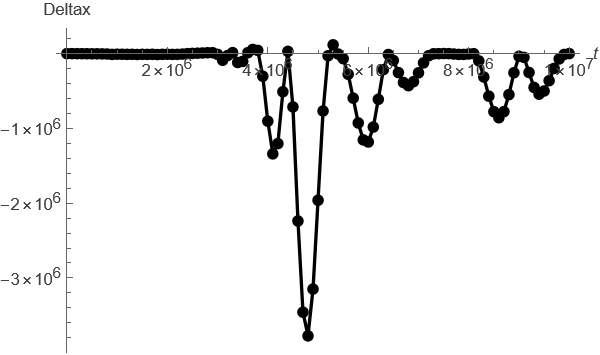
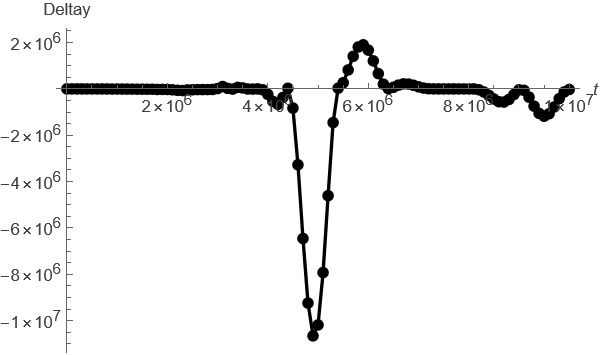

In [255]:
PLOTDeltax1= ListPlot[DeltaxNumArray,PlotRange->All,PlotStyle->{Black} ,Joined->True,PlotMarkers->Automatic,AxesLabel->{t,"Deltax"}]
PLOTDeltay1= ListPlot[DeltayNumArray,PlotRange->All,PlotStyle->{Black} ,Joined->True,PlotMarkers->Automatic,AxesLabel->{t,"Deltay"}]

## 

### <a class="anchor" id="5_Questions"></a> 5. Questions 

[Back to Table of Contents](#Table_of_Contents)  

**1.** Discuss the possible reasons for the difference between the observed period of revolution and the period of revolution computed numerically from the radial differential equation (Sec. 2.1). How do 
the periods of revolution computed numerically from the radial differential equation or analytically (Sec. 3) differ from each other? 

Regarding the difference between the observed revolution and the period of revolution computed numerically from the radial differential equation (or even the analytical obtained from Kepler's law), here our model is an ideal Newtonian two-body Kepler problem. The real planet’s motion (and published ephemerides) includes perturbations from other planets, the oblateness of the Sun (small), and post-Newtonian relativistic corrections (perihelion precession, tiny effect per orbit). Although over one orbit these effects are small but it can still produce percent level differences in some reported quantities depending on how the “period” is defined. It is also possible that the quoted value used a different constant for the Sun’s gravitational parameter or slightly different conversion factors.

Now for the differences found between the obtained analytical and numerical periods, the analytical Kepler period is exact for a closed two-body orbit and depends solely on the semi-major axis. In contrast, the period extracted from the numerical radial solution is affected by integration tolerances, interpolation of the turning points, and slight numerical drift in quantities such as angular momentum and orbital elements. Some of the affecting factors include:

          -Method & solver behavior: adaptive-step solvers vary step sizes; the method setting "StiffnessSwitching" which switches dynamically between stiff vs nonstiff solvers, and the "NonstiffTest" -> False method, which improves the stability of the solver, may cause the local truncation error to accumulate differently.

          -Numerical integration errors: using finite tolerances (AccuracyGoal, PrecisionGoal) and finite-step integration causes tiny errors in energy and phase that shift the time of aphelion.

          -Finding the period via radial maximum: the numerical procedure FindMaximum or sampling may not locate the true continuous-time maximum precisely if the solution is represented numerically; interpolant accuracy matters.

**2.** Answer the question in Sec. 4.2 

This was answered in section 4.2.

**3.** Keeping the Method constant, how does the error in *both* the conserved quantities and in *position* behave as a function of `AccuracyGoal->n,PrecisionGoal->n`, with $n$ an integer? 

In [281]:
errors = Table[Module[{Sol, rSoln, thetaSoln, xSoln, ySoln,(* error storage *)maxAngMomError, maxPositionError},
(* Solve the ODE with accuracy n*)
Sol = NDSolve[{r''[t] == (lSpecAngMom[r0,vt0])^2 (1/(r[t])^3) - (kSun/(r[t])^2) ,
               ThetaAng'[t] == (lSpecAngMom[r0,vt0])(1/(r[t])^2),
               r[0]==r0, r'[0]== +0, ThetaAng[0]== 0},
               {r,ThetaAng},{t,0,tfin},
               AccuracyGoal-> n, PrecisionGoal-> n, 
               MaxSteps-> ∞, Method -> {"StiffnessSwitching","NonstiffTest"->False}][[1]];
               
(* numerical functions *)
rSoln[t_] = r[t] /. Sol;
thetaSoln[t_] = ThetaAng[t] /. Sol;

xSoln[t_] = rSoln[t]*Cos[thetaSoln[t]];
ySoln[t_] = rSoln[t]*Sin[thetaSoln[t]];

(* 1. Max angular momentum error over the orbit *)
maxAngMomError = Max@Table[(Abs[((rSoln[t]^2)*thetaSoln'[t])- lSpecAngMom0])/lSpecAngMom0,
                           {t, 0, tfin, tfin/500}];
(* 2. Max position error compared to analytic solution *)
maxPositionError = Max@Table[(Sqrt[(xSoln[t] - (xAnalyt[69.82*10^9,38.8569*10^3,ThetaAnalyt] /. ThetaAnalyt -> thetaSoln[t]))^2 +(ySoln[t] - (yAnalyt[69.82*10^9,38.8569*10^3,ThetaAnalyt] /. ThetaAnalyt -> thetaSoln[t]))^2]),
                                {t, 0, tfin, tfin/500}];
                        {n, maxAngMomError, maxPositionError}], {n,5,18}]


6                             7
{{5, 0.00128866, 2.73005 10 }, {6, 0.00483486, 1.23478 10 }, 
 
                             7                             7
>   {7, 0.0068833, 1.33463 10 }, {8, 0.00688244, 1.42624 10 }, 
 
                              7                              7
>   {9, 0.00473036, 1.21474 10 }, {10, 0.00692346, 1.39404 10 }, 
 
                               6                              6
>   {11, 0.00406637, 6.18227 10 }, {12, 0.00302061, 5.73239 10 }, 
 
                               6                              6
>   {13, 0.00215766, 6.09477 10 }, {14, 0.00127489, 2.02433 10 }, 
 
                                6
>   {15, 0.000723963, 1.51071 10 }, {16, 0.000458423, 419598.}, 
 
>   {17, 0.0000258112, 42680.7}, {18, 0.000012161, 42681.3}}

-Graphics-
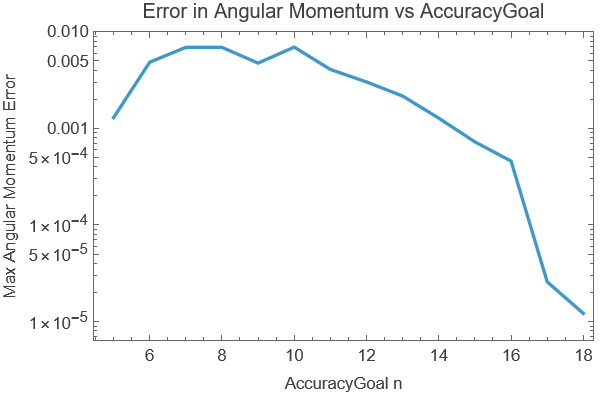

In [282]:
AngMomError= ListLogPlot[errors[[All, {1, 2}]],Joined -> True, Frame -> True,
  FrameLabel -> {"AccuracyGoal n", "Max Angular Momentum Error"},
  PlotLabel -> "Error in Angular Momentum vs AccuracyGoal"]


In [283]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q3a-fig-7-AngMomErr-vs-AccuracyGoal.pdf", AngMomError]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q3a-fig-7-AngMomErr\
 
>   -vs-AccuracyGoal.pdf

Once n exceeds 10, the error starts decreasing almost drastically towards 0

-Graphics-
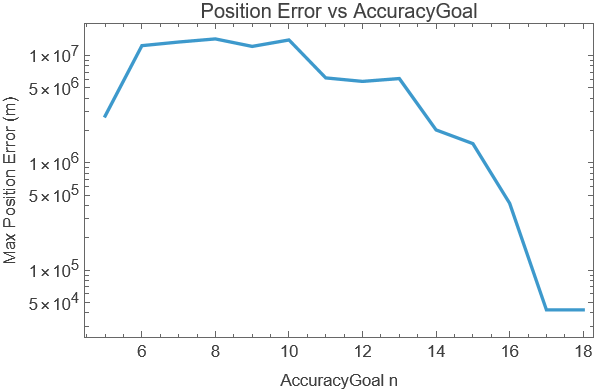

In [288]:
PositionError= ListLogPlot[errors[[All, {1, 3}]],Joined -> True,Frame -> True,
  FrameLabel -> {"AccuracyGoal n", "Max Position Error (m)"},
  PlotLabel -> "Position Error vs AccuracyGoal"]

In [289]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q3b-fig-8-PositionErr-vs-Accuracy.pdf", PositionError]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q3b-fig-8-PositionE\
 
>   rr-vs-Accuracy.pdf

Once n exceeds 10, the error starts dropping linearly almost 

**4.** Keeping the Method constant, how does the Timing result behave as a function of `AccuracyGoal->n,PrecisionGoal->n`, with $n$ an integer? 

When the ODE solver method is kept fixed, increasing AccuracyGoal = n and PrecisionGoal = n significantly increases the computation time.
This occurs because the adaptive integrator must take smaller steps and more correction iterations to satisfy the higher accuracy target, while simultaneously using higher-precision arithmetic whose cost grows polynomially with n.
As a result, the timing grows superlinearly, often close to exponential growth for n > 12.
Therefore, increasing numerical precision improves accuracy but has a strong cost in computational effort.

-Graphics-
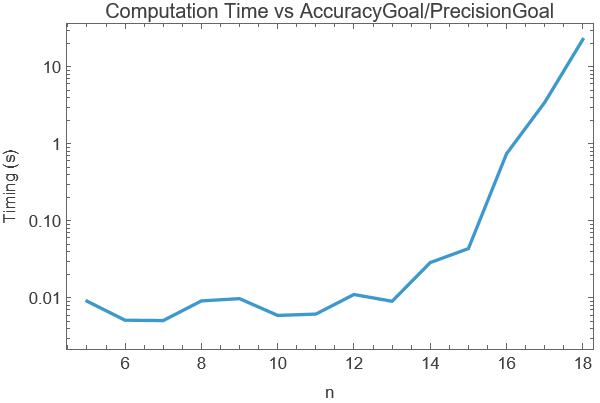

In [302]:
timings = Table[Module[{t}, t = First @ AbsoluteTiming[
                            NDSolve[{r''[t] == (lSpecAngMom[r0, vt0])^2/r[t]^3 - kSun/r[t]^2,
                                     ThetaAng'[t] == lSpecAngMom[r0, vt0]/r[t]^2,
                                     r[0] == r0, r'[0] == 0, ThetaAng[0] == 0},
                                     {r, ThetaAng}, {t, 0, tfin},
                                     AccuracyGoal -> n, PrecisionGoal -> n,
                                     Method -> {"StiffnessSwitching", "NonstiffTest" -> False}, MaxSteps -> ∞]];
                            {n, t}],{n, 5,18}];

TimingPlot= ListLogPlot[timings, Joined -> True, Frame -> True, FrameLabel -> {"n", "Timing (s)"},
            PlotLabel -> "Computation Time vs AccuracyGoal/PrecisionGoal"]

In [304]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q4-fig-9-Timing-vs-AccuracyGoal.pdf", TimingPlot]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q4-fig-9-Timing-vs-\
 
>   AccuracyGoal.pdf

It is clear that timing increases the higher we want our accuracy goal to be.

6
7.60071 10
-Graphics-
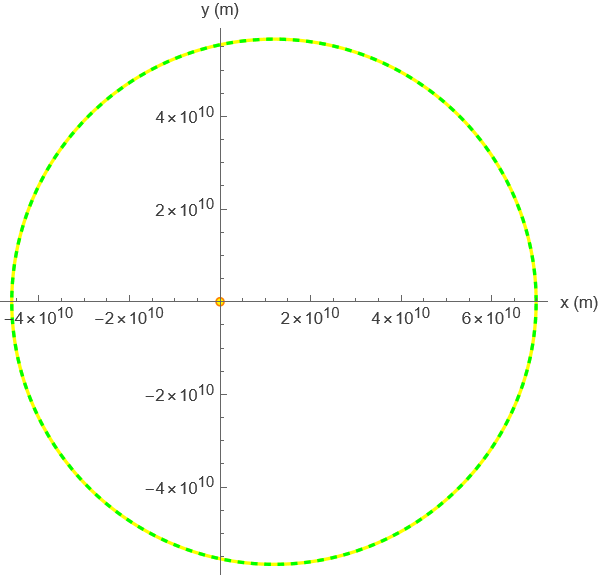

In [309]:
(* Symplectic Leapfrog Integrator for Two-Body Problem-Manual *)
nSteps = 10000;
dtSym = tfin/nSteps;

rSymList = ConstantArray[0, nSteps + 1];
pSymList = ConstantArray[0, nSteps + 1]; 
thetaSymList = ConstantArray[0, nSteps + 1];

(* initial conditions *)
rSymList[[1]] = r0;
pSymList[[1]] = 0;  
thetaSymList[[1]] = 0;

(* radial force derivative of Hamiltonian *)
fr[r_] := (lSpecAngMom[r0, vt0]^2)/r^3 - (kSun/r^2);

Do[pHalf = pSymList[[i]] + (dtSym/2)*fr[rSymList[[i]]];
  (* full-step radius update *)
  rNew = rSymList[[i]] + dtSym*pHalf;
  (* complete momentum update *)
  pNew = pHalf + (dtSym/2)*fr[rNew];
  (* theta update *)
  thetaNew = thetaSymList[[i]] + dtSym*( lSpecAngMom[r0, vt0] / rNew^2 );

  rSymList[[i + 1]] = rNew;
  pSymList[[i + 1]] = pNew;
  thetaSymList[[i + 1]] = thetaNew;
  ,{i, 1, nSteps}];

xSymList = rSymList*Cos[thetaSymList];
ySymList = rSymList*Sin[thetaSymList];

tSymList = Table[(i - 1)*dtSym, {i, 1, nSteps + 1}];
rSymInterpolation = Interpolation[Table[{tSymList[[i]], rSymList[[i]] }, {i, 1, Length[tSymList]}]];
TSym = FindMaximum[rSymInterpolation[t], {t, tfin/2, tfin}][[2, 1, 2]]

thetaAnalList = thetaSymList;
xAnalList = Table[rAnalyt[r0, vt0, thetaAnalList[[i]]] * Cos[thetaAnalList[[i]]],
    {i, 1, Length[thetaAnalList]}];

yAnalList = Table[rAnalyt[r0, vt0, thetaAnalList[[i]]] * Sin[thetaAnalList[[i]]],
    {i, 1, Length[thetaAnalList]}];

   
DeltaXSym = Table[ xSymList[[i]] - xAnalList[[i]], {i, 1, Length[xSymList]} ];
DeltaYSym = Table[ ySymList[[i]] - yAnalList[[i]], {i, 1, Length[ySymList]} ];

combinedTrajSym = Table[{xSymList[[i]], ySymList[[i]]}, {i, 1, Length[xSymList]}];

combinedTrajAnal = Table[{xAnalList[[i]], yAnalList[[i]]},{i, 1, Length[xAnalList]}];

PLOTSym = Graphics[{Yellow, Thick, Line[combinedTrajSym]}];

PLOTTSYM = Show[PLOTSun,PLOTSym,PLOTMercuryTrajAnalyt,
   PlotRange -> All,
   Axes -> True,
   AspectRatio -> 1,
   AxesLabel -> {"x (m)", "y (m)"}]


In [337]:
TAnal =RevolutionPeriod[69.82 10^9,38.8569 10^3]
ErrorPeriodSym = (TSym - TAnal)/TAnal

6
7.60072 10
          -7
-5.8679 10

In [339]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Symplectic-fig-11-SYM.pdf", PLOTTSYM]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Symplectic-fig-11-S\
 
>   YM.pdf

6
7.60071 10
-Graphics-
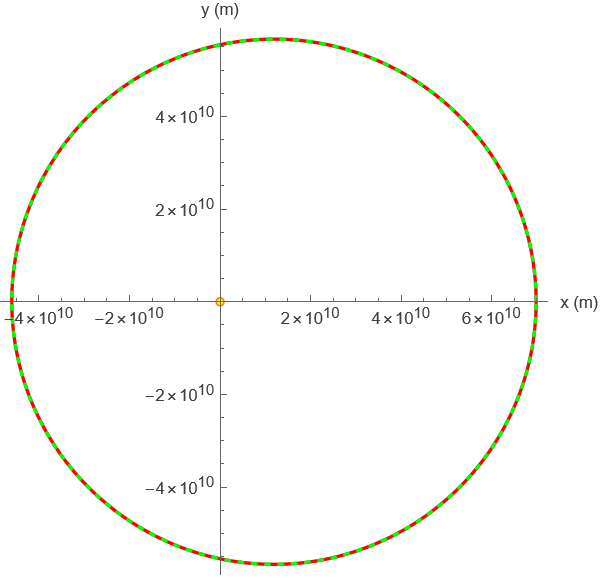

In [340]:
l = lSpecAngMom[r0, vt0];

eqnsRK = {r''[t] == l^2/r[t]^3 - kSun/r[t]^2, theta'[t] == l/r[t]^2, r[0] == r0, r'[0] == 0, theta[0] == 0};

solRK = NDSolve[eqnsRK,{r, theta},{t, 0, tfin},Method -> "ExplicitRungeKutta", AccuracyGoal-> 15, PrecisionGoal-> 15, MaxSteps -> ∞][[1]];

rSolRK[t_] := r[t] /. solRK;
thetaSolRK[t_] := theta[t] /. solRK;

TRK = FindMaximum[rSolRK[t], {t, tfin/2, tfin}][[2, 1, 2]]

xRK[t_] := rSolRK[t] Cos[thetaSolRK[t]];
yRK[t_] := rSolRK[t] Sin[thetaSolRK[t]];

trajRK = ParametricPlot[{xRK[t], yRK[t]},{t, 0, tfin}, PlotStyle -> {Red, Thick}];

PLOTTRK = Show[PLOTSun,trajRK,PLOTMercuryTrajAnalyt,
   PlotRange -> All,
   Axes -> True,
   AspectRatio -> 1,
   AxesLabel -> {"x (m)", "y (m)"}]


In [350]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-11-RK.pdf", PLOTTRK]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-11-RK.pdf

In [351]:
tfin

10000000

6
7.60071 10
-Graphics-
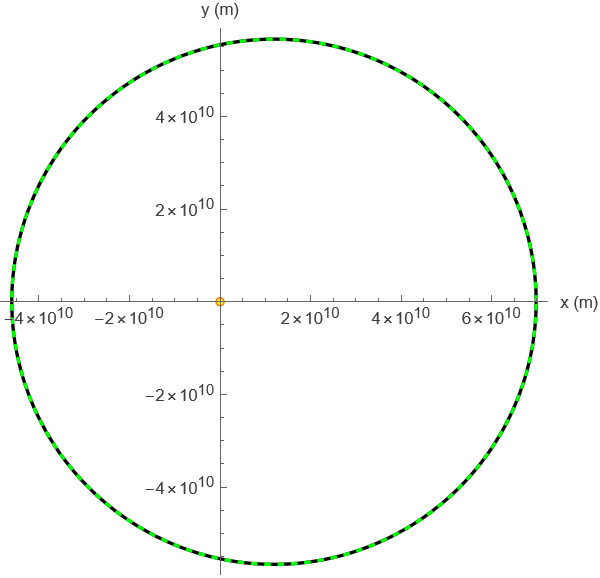

In [352]:
(* --- Dimensionless time variable --- *)
Clear[r, pr, τ];

(* Angular momentum *)
l = lSpecAngMom[r0, vt0];

(* Dimensionless equations *)
eqnsSymND = {r'[τ] == tfin pr[τ], pr'[τ] == tfin (l^2/r[τ]^3 - kSun/r[τ]^2),
            r[0] == r0, pr[0] == 0};

SymplecticLeapfrog = {"SymplecticPartitionedRungeKutta","DifferenceOrder" -> 2,"PositionVariables" -> {r}};

solSym = NDSolve[eqnsSymND,{r, pr},{τ, 0, 1},
  Method -> SymplecticLeapfrog,
  MaxStepSize -> 1/10000,AccuracyGoal -> 15,PrecisionGoal -> 15, MaxSteps -> ∞][[1]];

(* Radial solution *)
rSolSym[τ_] := r[τ] /. solSym;

(* Theta integration (dimensionless time) *)
thetaSol = NDSolve[{theta'[τ] == tfin l/rSolSym[τ]^2, theta[0] == 0},
                    theta,{τ, 0, 1}, MaxStepSize -> 1/10000, MaxSteps -> ∞][[1]];

thetaSolSym[τ_] := theta[τ] /. thetaSol;

TSym2 = tfin * FindMaximum[rSolSym[τ], {τ, 0.5, 1}][[2, 1, 2]]

(* Trajectory *)
xSym[τ_] := rSolSym[τ] Cos[thetaSolSym[τ]];
ySym[τ_] := rSolSym[τ] Sin[thetaSolSym[τ]];

trajSym = ParametricPlot[{xSym[τ], ySym[τ]},{τ, 0, 1}, PlotStyle -> {Black, Thick}];

PLOTTLF = Show[PLOTSun,trajSym,PLOTMercuryTrajAnalyt, PlotRange -> All,
  Axes -> True,
  AspectRatio -> 1,
  AxesLabel -> {"x (m)", "y (m)"}]

In [371]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-11-LF.pdf", PLOTTLF]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-11-LF.pdf

In [372]:
NumberForm[TRK, {Infinity, 15}]
NumberForm[TSym, {Infinity, 15}]
NumberForm[TSym2, {Infinity, 15}]
NumberForm[TAnal,{Infinity, 15}]
ErrorPeriodSym = (TSym - TAnal)/TAnal
ErrorPeriodSym2 = (TSym2-TAnal)/TAnal
ErrorPeriodRK = (TRK-TAnal)/TAnal

6
7.600714131148754 × 10
                      6
7.600713872578831 × 10
                      6
7.600714131145510 × 10
                      6
7.600718332601069 × 10
          -7
-5.8679 10
           -7
-5.52771 10
          -7
-5.5277 10

Method                  Period                    Relative Error

                                              6
Analytical              7.600718332601069 × 10    0

                                              6                          -7
Symplectic (manual)     7.600713872578831 × 10    -5.867895695969338 × 10

                                              6                          -7
Symplectic (Leapfrog)   7.600714131145510 × 10    -5.527708534548106 × 10

                                              6                          -7
Runge–Kutta             7.600714131148754 × 10    -5.527704265572848 × 10
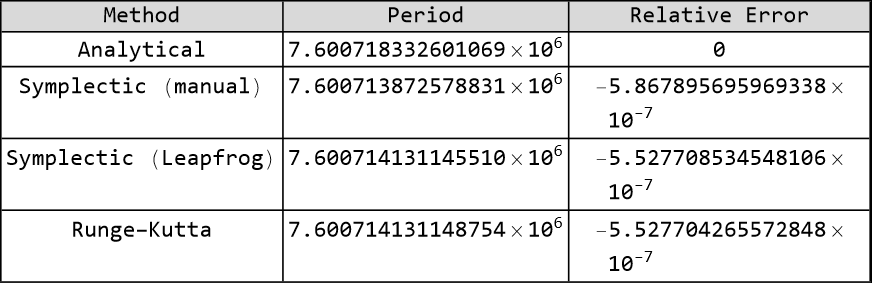

In [751]:
format[x_] := NumberForm[x, {Infinity, 15}]
formatErr[x_] := NumberForm[x, {Infinity, 15}]

periodTableFormatted = {{"Method", "Period", "Relative Error"},
                        {"Analytical", format[TAnal], 0},
                        {"Symplectic (manual)", format[TSym], formatErr[ErrorPeriodSym]},
                        {"Symplectic (Leapfrog)", format[TSym2], formatErr[ErrorPeriodSym2]},
                        {"Runge–Kutta", format[TRK], formatErr[ErrorPeriodRK]}};

Grid[periodTableFormatted,Frame -> All,Alignment -> Center,Background -> {None, {LightGray, None}},ItemStyle -> Directive[14]]


In [746]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-11-TABLE.jpeg", periodTableFormatted]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-fig-11-TABLE.jpeg

**5.** Consider a spacecraft in orbit around the Earth in an orbit with perigee and apogee *altitudes* equal to $250$ km and the semimajor axis of the Moon, respectively. At the initial time, the spacecraft is at perigee. Extract a random time by replacing the number 12345 by the last $5$ digits of your cell phone number in `SeedRandom`:

In [388]:
SeedRandom[53762]; (RandomReal[{1, 6}]) SiderealDay 

111909.

By copying all needed cells *above* this cell and by modifying them as needed, do the following: 

**5.1** Follow the same procedure as above and **plot** the trajectory of the spacecraft from the initial time ($t=0$) till the time you randomly extracted, in seconds. You only need to do this numerically. <br> 

-Graphics-
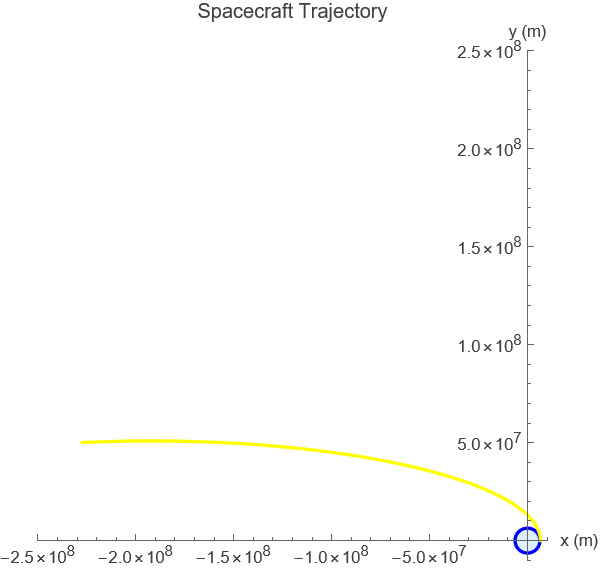

In [393]:
kEarth = 3.986004418*10^14;
RE = 6371*10^3;
hPerigee = 250*10^3;
aMoon = 384400*10^3;

rp5 = RE + hPerigee;
ra5 = RE + aMoon;

a5 = (rp5 + ra5)/2;
e5 = (ra5 - rp5)/(ra5 + rp5);

vp5 = Sqrt[kEarth*(2/rp5 - 1/a5)];

(* Initial conditions *)
r00 = rp5;
dr00 = 0;
theta00 = 0;
dtheta00 = vp5/rp5;

TPeriod5 = 2*Pi*Sqrt[a5^3/kEarth];


tfin5 = 111909;


ODE = {r''[t] == r[t]*(theta'[t])^2 - kEarth/(r[t]^2),
       theta''[t] == -(2*r'[t]*theta'[t])/r[t],
       r[0] == r00, r'[0] == dr00, theta[0] == theta00, theta'[0] == dtheta00};


solv = NDSolve[ODE, {r, theta}, {t, 0, tfin5},
               AccuracyGoal -> 15, PrecisionGoal -> 15,
               MaxSteps-> ∞, Method -> {"StiffnessSwitching","NonstiffTest"->False}][[1]];

(*Plotting the trajectory*)
x[t_] := (r[t] /. solv) * Cos[theta[t] /. solv];
y[t_] := (r[t] /. solv) * Sin[theta[t] /. solv];

trajectoryPlot = ParametricPlot[{x[t], y[t]}, {t, 0, tfin5}, Axes->True, PlotRange -> All,AspectRatio -> 1, PlotStyle -> {Yellow, Thick}];

(* Earth graphics *)
earthCircle = Graphics[{Blue, Thick, Circle[{0, 0}, RE]}];
earthDisk   = Graphics[{LightBlue, Disk[{0, 0}, RE]}];

(* Final plot *)
PlotOrbitAll = Show[earthDisk, earthCircle, trajectoryPlot, Axes -> True, AxesLabel -> {"x (m)", "y (m)"}, AspectRatio -> 1, 
PlotRange -> {{-2.5*10^8,10^7},{-10^7,2.5*10^8}},
PlotLabel -> "Spacecraft Trajectory"]

In [420]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q5-fig-10-Spacecraft-Trajectory.pdf", PlotOrbitAll]

C:/Users/akaou/OneDrive/Desktop/AE-311/Figures/kaoutar-ammara-report-Q5-fig-10-Spacecraf\
 
>   t-Trajectory.pdf

**5.2** Provide the **final state** of the spacecraft in polar coordinates, that is: <br> 

$r(t_{\mathrm{fin}})$<br> 
$\dot{r}(t_{\mathrm{fin}})$<br> 
$\theta(t_{\mathrm{fin}})$<br> 
$\dot{\theta}(t_{\mathrm{fin}})$. <br> 

In [425]:
rFin = r[tfin5] /. solv // N
rdotFin = r'[tfin5] /. solv // N
thetaFin = theta[tfin5] /. solv // N
thetadotFin = theta'[tfin5] /. solv // N

8
2.32758 10
1150.28
2.92483
          -6
1.32981 10

**5.3**  Also, what is the distance of the spacecraft from apogee at the final time?

In [433]:
distanceFromApogee = ra5 - rFin

8
1.58013 10

## <a class="anchor" id="References"></a> References 

[Back to Table of Contents](#Table_of_Contents) 

R. R. Bate, D. D. Mueller, and J. E. White, *Fundamentals of Astrodynamics* (Dover Publications, New York, 1971). <br> 
https://archive.org/details/BateMuellerAndWhiteFundamentalsOfAstrodynamics/

R. P. Feynman, R. B. Leighton, and M. Sands, *The Feynman's Lectures on Physics* (Caltech, Pasadena, 1963). <br> 
https://archive.org/details/Feynman_201811/feynman%20vol.1/mode/2up

H. Goldstein, C. Poole, and J. Safko, *Classical Mechanics* (Addison-Wesley, San Francisco, 2002). <br>
https://archive.org/details/HerbertGoldsteinCharlesPooleJohnSafkoClassicalMechanics3rdEd 

C. Kittel, W. D. Knight, and M. A. Ruderman, *Berkeley Physics Course Vol. 1 (Mechanics)* (McGraw Hill Book Company, New York, 1973). <br>
https://archive.org/details/BerkeleyPhysicsCourse 

## <a class="anchor" id="Additional_reading"></a> Additional reading 

[Back to Table of Contents](#Table_of_Contents) 

Implementation of symplectic methods including the leapfrog method within Mathematica: 

https://reference.wolfram.com/language/tutorial/NDSolveSplitting.html 


## <a class="anchor" id="ChangeLog"></a> ChangeLog

[Back to Table of Contents](#Table_of_Contents) 

### v. 1.0

2023-09-20&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* File created. 

### v. 1.1

2023-09-20&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* Questions updated 

### v. 1.2

2023-11-19&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* Added Sections 6 and 7. 

### v. 1.3

2024-11-24&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* Removed Sections 6 and 7 to a different document. 


<div class="alert alert-block alert-info">
<span style='color:black'>  "Numerical solution of the 2-body problem" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

 <div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 